# Bologna Transit Analysis - Step 01: Centralita' Microscopica e Bottleneck

Questo notebook analizza la rete a livello microscopico per individuare gli snodi fondamentali e le stazioni "gatekeeper" (colli di bottiglia).
Calcoliamo:
- **Degree Centrality**: Stazioni con più incroci fisici di linee.
- **Closeness Centrality (Weighted)**: Stazioni geometricamente baricentriche rispetto ai tempi di percorrenza.
- **Betweenness Centrality (Weighted)**: Stazioni attraverso cui passano la maggior parte dei percorsi minimi (colli di bottiglia).

In [1]:
import sys
sys.path.append('..')
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader_bologna import load_bologna_network
from src.analyzer_bologna import compute_centralities

## 1. Calcolo delle Misure di Centralita'

In [2]:
G_bus, _, _, _, _ = load_bologna_network(include_tram=False)
df_micro = compute_centralities(G_bus)

print("=== Top 5 Hubs per Grado (Incroci di Linea) ===")
print(df_micro.sort_values(by='Degree', ascending=False).head(5)[['Station', 'Degree']])

print("\n=== Top 5 Bottlenecks (Betweenness Centrality) ===")
print(df_micro.sort_values(by='Betweenness Centrality', ascending=False).head(5)[['Station', 'Betweenness Centrality']])

=== Top 5 Hubs per Grado (Incroci di Linea) ===
                Station  Degree
7             Due Torri       5
0      Bologna Centrale       4
28  Porta Santo Stefano       4
26        Porta Mazzini       4
22      Porta Saragozza       4

=== Top 5 Bottlenecks (Betweenness Centrality) ===
             Station  Betweenness Centrality
0   Bologna Centrale                0.236453
15  Porta San Felice                0.236453
2       XX Settembre                0.216749
22   Porta Saragozza                0.147783
4        Via Marconi                0.120690


## 2. Visualizzazione degli Snodi Sensibili (Heatmap di Betweenness)

I nodi più grandi e caldi rappresentano i punti critici in cui si accumulano i percorsi minimi dei passeggeri.

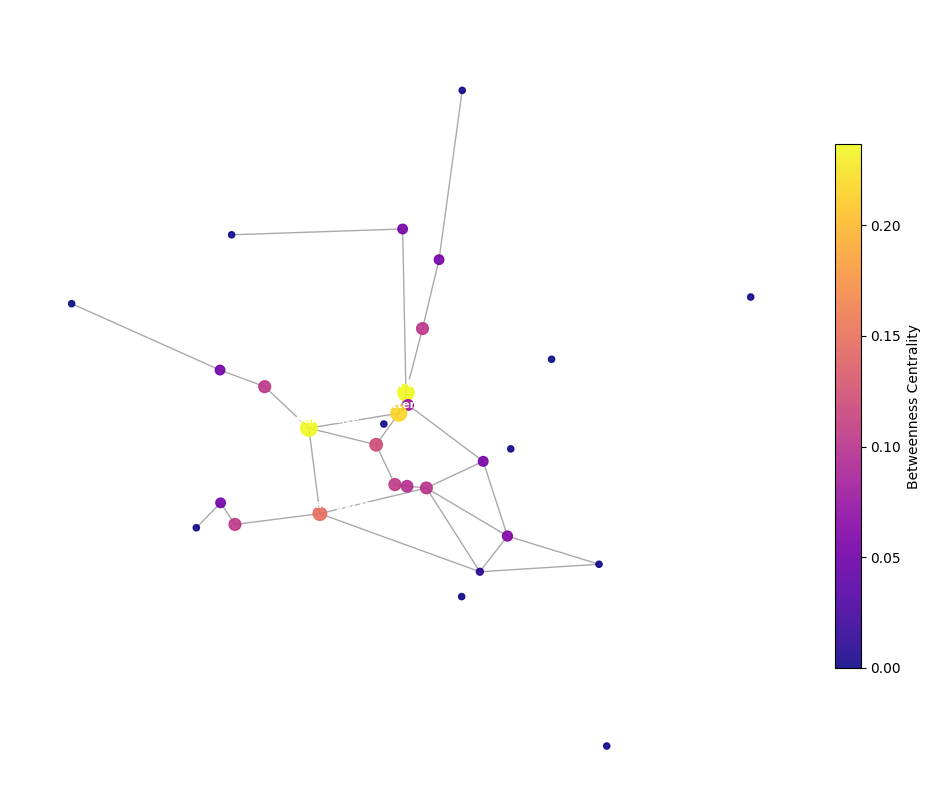

In [3]:
pos = {node: (data['lon'], data['lat']) for node, data in G_bus.nodes(data=True)}
bet_dict = dict(zip(df_micro['Station'], df_micro['Betweenness Centrality']))
node_sizes = [20 + 500 * bet_dict.get(node, 0) for node in G_bus.nodes()]
node_colors = [bet_dict.get(node, 0) for node in G_bus.nodes()]

plt.figure(figsize=(10, 8))
plt.gca().set_facecolor('#1a1a1a')
nx.draw_networkx_edges(G_bus, pos, edge_color='#555555', width=1, alpha=0.5)
sc = nx.draw_networkx_nodes(G_bus, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.plasma, alpha=0.9)
plt.colorbar(sc, label='Betweenness Centrality', shrink=0.7)

top_bot = df_micro.sort_values(by='Betweenness Centrality', ascending=False).head(4)['Station'].tolist()
label_p = {name: (pos[name][0], pos[name][1] + 0.001) for name in top_bot}
nx.draw_networkx_labels(G_bus, label_p, labels={name: name for name in top_bot}, font_color='white', font_size=8, font_weight='bold')

plt.title("Bologna: Colli di Bottiglia nella Rete Autobus", color='white', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()